# SMS Spam Detection Machine Learning Project

In this project, we will demonstrate how to build three different deep learning models using Tensorflow, a popular machine learning library for Python codes. As we build and train each one, we will compare each one based on four metrics:

* Accuracy — the overall percentage of correctly classified emails. A higher accuracy score is essential for effective spam detection.
* Precision — The ratio of true positive results to all positive results predicted by the model. High precision means fewer HAM (actual) emails are misclassified.
* Recall — The ratio of true positive results to all actual positives in the dataset. High recall means fewer spam emails slip through.
* F1-score — the harmonic mean of precision and recall; the best single number to compare models when the classes are imbalanced.

Disclaimer: Each model may be prone to mistakes. Factors that may affect its performance are the quality of training data, which machine learning algorithms it uses, the characteristics of emails being analyzed, and the volume of emails from a sender. Models may also yield slightly different results than what is shown.

# Import Libraries and Dataset

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
#importing additional libraries
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

# Data Cleanup

In [ ]:
#cleaning and clarifying dataset
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv',encoding="latin-1")
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

In [ ]:
#dropping duplicates
df.info()
df.isnull().sum()
df.duplicated().sum
df.drop_duplicates(inplace=True)
df.head()

# Exploratory Data Analysis

In [ ]:
#Percentage of ham vs. spam emails
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [ ]:
#creating new numeric columns that will further seperate ham vs spam. Hint= spam emails are usually longer.
df["text"] = df["text"].str.lower()
df["char_cnt"]     = df["text"].str.len()
df["word_cnt"]     = df["text"].str.split().str.len()
df["avg_word_len"] = df["char_cnt"] / df["word_cnt"]

df.head()

In [ ]:
#Visualizing the numbers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features = ["char_cnt", "word_cnt", "avg_word_len"]

for ax, feat in zip(axes, features):
    for label, color in [("ham", "blue"), ("spam", "red")]:
        df[df["label"] == label][feat].plot(
            kind="hist", bins=40, alpha=0.6, color=color, label=label, ax=ax
        )
    ax.set_title(feat)
    ax.legend()

plt.suptitle("Feature distributions by class", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
numberic_df= df.select_dtypes(include=['number'])
sns.heatmap(numberic_df.corr(), annot=True)

# Splitting data and Text Vectorization

In [ ]:
#Splitting data
X_train, X_test, y_train, y_test= train_test_split(
    df['text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)
X_train_np= X_train.to_numpy()
X_test_np= X_test.to_numpy()
y_train_np= y_train.to_numpy()
y_test_np= y_test.to_numpy()

In [ ]:
#computing text stats for vectorization
avg_words_len = round(sum([len(i.split())
          for i in df['text']]) / len(df['text']))
total_words_length = len(set("".join(df['text']).split()))
print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

In [ ]:
#Helper functions
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history
def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y,y_preds),
        'precision': precision_score(y,y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

In [ ]:
#Text Vectorization layer
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize= 'lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

# Building and Training the Models

In [ ]:
#Dense embedding model
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

In [ ]:
#Bidirectional LSTM Model, Building and Training
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2= compile_and_fit(model_2)

In [ ]:
#Universal Sentence Encoder for transferring learning
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

In [ ]:
#Collecting performance metrics for all models
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}
results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

# Results

In [ ]:
#Visualizing Results
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

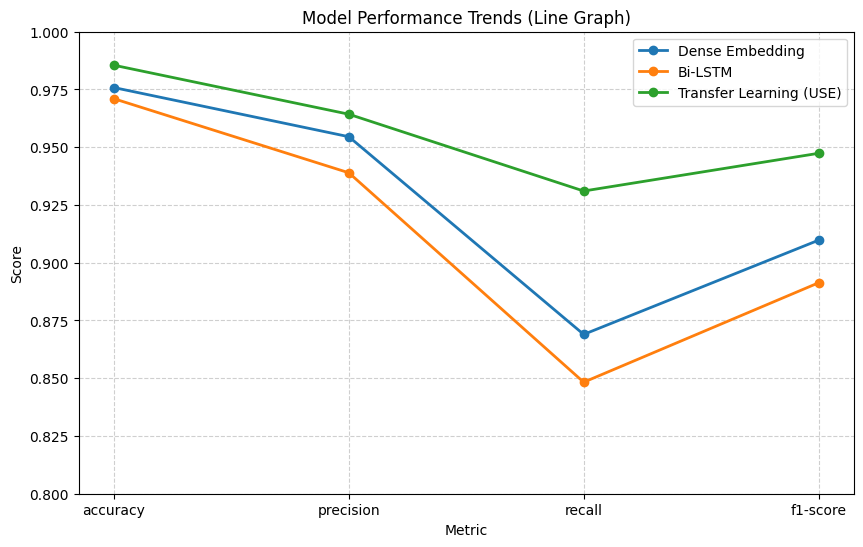

In [22]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# CONCLUSION

Based on what’s shown in the graphs, it seems that the **Transfer Learning (USE)** seems to be the most effective in spam detection for this dataset due to its high accuracy score and F1 score. Additionally, it requires significantly less data due to its pre-trained embeddings. Though it requires a deeper contextual understanding of sequences, this can be helpful in this project for filtering out spam emails. The other two models, having the same line shape as the USE model, all recieved lower scores than the Transfer Learning (USE) model, with the Bi-LSTM model being the lowest. This may increase the risk of legitimate emails being wrongly blocked.